In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Cargar los datos
clientes = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/clientes.csv")
churn = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/churn_target.csv")
calidad = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/calidad_senal_zona_mensual.csv")

# 2. Convertir fechas correctamente
churn["fecha"] = pd.to_datetime(churn["fecha"], format="mixed", dayfirst=True)
calidad["fecha"] = pd.to_datetime(calidad["fecha"], format="mixed", dayfirst=True)

# 3. Quitar clientes duplicados
clientes = clientes.drop_duplicates("cliente_id")

In [13]:


# 4. Agrupar calidad por zona y mes
calidad = calidad.groupby(["zona_id", "fecha"], as_index=False).agg({
    "region": "first",
    "tipo_zona": "first",
    "poblacion_zona": "first",
    "cobertura_4g_pct": "mean",
    "cobertura_5g_pct": "mean",
    "latencia_ms": "mean",
    "velocidad_media_mbps": "mean",
    "tasa_cortes_pct": "mean",
    "indice_calidad_global": "mean",
    "incidencia_masiva": "max"
})

# 5. Crear variables temporales
calidad = calidad.sort_values(["zona_id", "fecha"])

calidad["calidad_mes_anterior"] = (
    calidad.groupby("zona_id")["indice_calidad_global"].shift(1)
)

calidad["calidad_media_3_meses"] = (
    calidad.groupby("zona_id")["indice_calidad_global"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)



Churn según calidad global:
grupo_calidad
muy baja    0.918521
baja        0.642976
alta        0.549225
muy alta    0.376041
Name: churn, dtype: float64

Churn según cortes de señal:
grupo_cortes
muy pocos     0.400967
pocos         0.505624
muchos        0.639372
muy muchos    0.953541
Name: churn, dtype: float64

Correlación con churn:
calidad_media_3_meses   -0.031287
calidad_mes_anterior    -0.029945
cobertura_4g_pct        -0.029054
indice_calidad_global   -0.027649
velocidad_media_mbps    -0.025084
cobertura_5g_pct        -0.022226
incidencia_masiva       -0.000814
latencia_ms              0.008412
tasa_cortes_pct          0.026836
churn                    1.000000
Name: churn, dtype: float64

Ranking de zonas con más churn:
         churn_pct  calidad_media  calidad_mes_anterior_media  \
zona_id                                                         
Z19       1.314459      22.045241                   21.945112   
Z07       1.294766      22.545997                   22.433252  

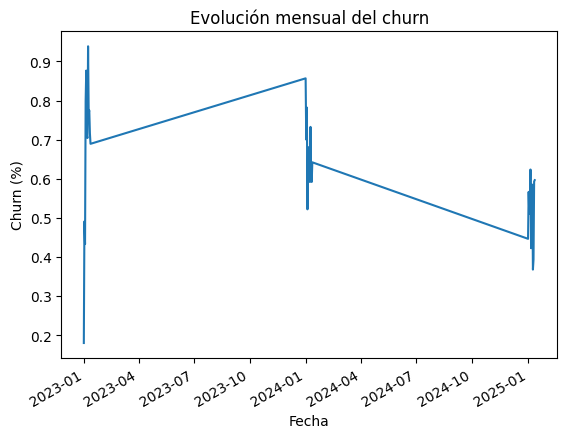

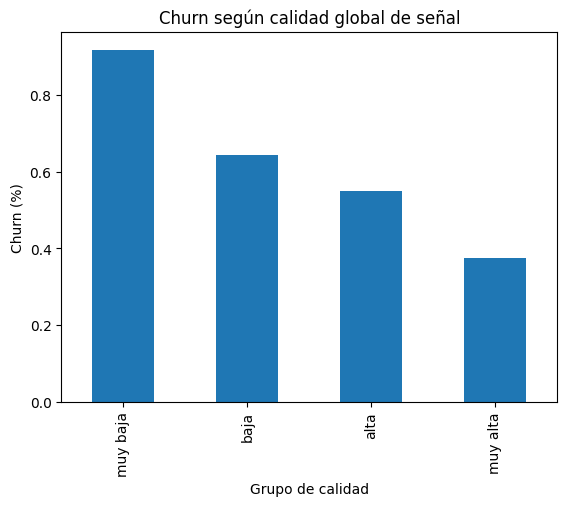

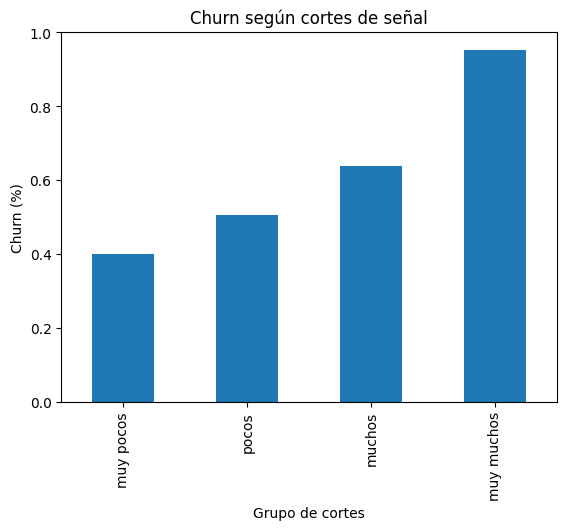


Ranking de zonas con cluster:
         churn_pct  calidad_media  calidad_mes_anterior_media  \
zona_id                                                         
Z19       1.314459      22.045241                   21.945112   
Z07       1.294766      22.545997                   22.433252   
Z01       1.224157      22.576179                   22.518735   
Z03       1.220703      22.119846                   21.998969   
Z06       1.208908      22.366216                   22.250189   
Z14       1.134700      21.891658                   21.822261   
Z25       1.118265      22.284774                   22.050191   
Z08       1.080939      21.862578                   21.760873   
Z21       1.014118      22.805588                   22.528820   
Z23       0.992351      21.802708                   21.684991   

         calidad_3_meses_media  cortes_medios  latencia_media  \
zona_id                                                         
Z19                  22.157511       3.107145       83.637

In [14]:
# 6. Unir churn con clientes
datos = churn.merge(
    clientes[["cliente_id", "zona_id"]],
    on="cliente_id",
    how="left"
)

# 7. Unir con calidad de señal
datos = datos.merge(
    calidad,
    on=["zona_id", "fecha"],
    how="left"
)

# 8. Análisis por calidad global
datos["grupo_calidad"] = pd.qcut(
    datos["indice_calidad_global"],
    4,
    labels=["muy baja", "baja", "alta", "muy alta"],
    duplicates="drop"
)

tabla_calidad = datos.groupby("grupo_calidad", observed=True)["churn"].mean() * 100

print("Churn según calidad global:")
print(tabla_calidad)

# 9. Análisis por cortes de señal
datos["grupo_cortes"] = pd.qcut(
    datos["tasa_cortes_pct"],
    4,
    labels=["muy pocos", "pocos", "muchos", "muy muchos"],
    duplicates="drop"
)

tabla_cortes = datos.groupby("grupo_cortes", observed=True)["churn"].mean() * 100

print("\nChurn según cortes de señal:")
print(tabla_cortes)

# 10. Correlaciones
variables = [
    "indice_calidad_global",
    "calidad_mes_anterior",
    "calidad_media_3_meses",
    "cobertura_4g_pct",
    "cobertura_5g_pct",
    "latencia_ms",
    "velocidad_media_mbps",
    "tasa_cortes_pct",
    "incidencia_masiva",
    "churn"
]

print("\nCorrelación con churn:")
print(datos[variables].corr(numeric_only=True)["churn"].sort_values())

# 11. Ranking de zonas
ranking_zonas = datos.groupby("zona_id").agg(
    churn_pct=("churn", lambda x: x.mean() * 100),
    calidad_media=("indice_calidad_global", "mean"),
    calidad_mes_anterior_media=("calidad_mes_anterior", "mean"),
    calidad_3_meses_media=("calidad_media_3_meses", "mean"),
    cortes_medios=("tasa_cortes_pct", "mean"),
    latencia_media=("latencia_ms", "mean"),
    velocidad_media=("velocidad_media_mbps", "mean"),
    cobertura_4g_media=("cobertura_4g_pct", "mean"),
    cobertura_5g_media=("cobertura_5g_pct", "mean")
).sort_values("churn_pct", ascending=False)

print("\nRanking de zonas con más churn:")
print(ranking_zonas.head(10))

# 12. Serie temporal de churn
churn_tiempo = datos.groupby("fecha")["churn"].mean() * 100

plt.figure()
churn_tiempo.plot()
plt.title("Evolución mensual del churn")
plt.xlabel("Fecha")
plt.ylabel("Churn (%)")
plt.show()

# 13. Gráfico churn según calidad global
plt.figure()
tabla_calidad.plot(kind="bar")
plt.title("Churn según calidad global de señal")
plt.xlabel("Grupo de calidad")
plt.ylabel("Churn (%)")
plt.show()

# 14. Gráfico churn según cortes
plt.figure()
tabla_cortes.plot(kind="bar")
plt.title("Churn según cortes de señal")
plt.xlabel("Grupo de cortes")
plt.ylabel("Churn (%)")
plt.show()

# 15. Clustering de zonas según calidad de red
variables_cluster = [
    "calidad_media",
    "cortes_medios",
    "latencia_media",
    "velocidad_media"
]

zonas_cluster = ranking_zonas[variables_cluster].dropna().copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(zonas_cluster)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
zonas_cluster["cluster"] = kmeans.fit_predict(X_cluster)

ranking_zonas = ranking_zonas.merge(
    zonas_cluster[["cluster"]],
    left_index=True,
    right_index=True,
    how="left"
)

print("\nRanking de zonas con cluster:")
print(ranking_zonas.head(10))

# 16. Resumen de clusters
resumen_clusters = ranking_zonas.groupby("cluster").agg(
    churn_medio=("churn_pct", "mean"),
    calidad_media=("calidad_media", "mean"),
    cortes_medios=("cortes_medios", "mean"),
    latencia_media=("latencia_media", "mean"),
    velocidad_media=("velocidad_media", "mean")
)

print("\nResumen de clusters:")
print(resumen_clusters)

# 17. Interpretación automática sencilla
print("\nCluster con mayor churn:")
print(resumen_clusters.sort_values("churn_medio", ascending=False).head(1))

print("\nCluster con mejor calidad:")
print(resumen_clusters.sort_values("calidad_media", ascending=False).head(1))